Энергетика: производство и потребление электроэнергии, цены на нефть и газ.


# Importing Required Libraries

In this section, we import the main Python libraries used for data analysis, visualization, and econometric modeling.

The following libraries are used:

- **pandas** — for working with tabular data
- **numpy** — for numerical computations
- **matplotlib** — for plotting graphs
- **seaborn** — for statistical visualization
- **statsmodels** — for time series modeling

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.model_selection import train_test_split
file_path = '../../data/'

##### Getting  Energetics related data through an API

In [ ]:
import yfinance as yf
import pandas as pd

def fetch_macro_energy_proxy(start_year="2010-01-01"):
    print("Загрузка данных по фьючерсам на нефть Brent (макроэкономический прокси)...")
    
    brent_data = yf.download("BZ=F", start=start_year, progress=False)
    
    brent_close = brent_data[['Close']].copy()
    brent_close.columns = ['Brent_Oil_Price']
    
    brent_monthly = brent_close.resample('MS').mean()
    
    brent_monthly = brent_monthly.ffill()
    brent_monthly.index.name = 'Date'
    
    return brent_monthly

df_energy = fetch_macro_energy_proxy(start_year="2010-01-01")


print(df_energy.head())

Загрузка данных по фьючерсам на нефть Brent (макроэкономический прокси)...
            Brent_Oil_Price
Date                       
2010-01-01        77.008421
2010-02-01        74.909999
2010-03-01        79.931304
2010-04-01        85.753810
2010-05-01        76.664737


 # Loading Exchange Rate Data

The exchange rate of the US dollar to the Kazakhstani tenge (USD/KZT) plays an important role in inflation dynamics.

Currency depreciation often leads to higher import prices and increased inflation.

In [53]:
import yfinance as yf

def fetch_exchange_rate(start_year="2010-01-01"):
    print("Fetching USD/KZT exchange rate...")
    # Download historical daily data
    kzt_data = yf.download("KZT=X", start=start_year, progress=False)
    
    # Isolate the closing price
    kzt_close = kzt_data[['Close']].copy()
    kzt_close.columns = ['USD_KZT']
    
    # Resample to monthly ('MS') to perfectly align with your other indicators
    kzt_monthly = kzt_close.resample('MS').mean()
    
    # Forward fill any missing days (like weekends/holidays)
    kzt_monthly = kzt_monthly.ffill()
    kzt_monthly.index.name = 'Date'
    
    return kzt_monthly

# Load the exchange rate
df_exchange = fetch_exchange_rate(start_year="2010-01-01")
print(df_exchange.head())

Fetching USD/KZT exchange rate...
               USD_KZT
Date                  
2010-01-01  176.019499
2010-02-01  175.621500
2010-03-01  174.950435
2010-04-01  174.465908
2010-05-01  174.192381


### Loading Unemployment Data And It's Indicators
In this section, we initialize the environment and load the primary target variable (Unemployment Rate) alongside the structural drivers identified in the labor market framework.


In [54]:
import pandas as pd
import re

def clean_annual(filepath, col_name):
    df = pd.read_excel(filepath, skiprows=10)
    df_total = df[df.iloc[:, 0] == 'РЕСПУБЛИКА КАЗАХСТАН'].copy()
    df_total = df_total.drop(df_total.columns[0], axis=1).transpose()
    df_total.columns = [col_name]
    df_total.index = df_total.index.astype(str).str.extract(r'(\d{4})')[0]
    df_total.index = pd.to_datetime(df_total.index + '-01-01')
    df_total[col_name] = df_total[col_name].astype(str).str.replace(r'\s+', '', regex=True)
    df_total[col_name] = pd.to_numeric(df_total[col_name], errors='coerce')
    return df_total.resample('MS').interpolate(method='pchip')


df_target = pd.read_excel(file_path+'unemployment_rate.xlsx', sheet_name='unemployed_rate', parse_dates=['Date']).set_index('Date')

df_agr = clean_annual(file_path + 'unemp/agricultural.xls', 'Agri_Emp')
df_ind = clean_annual(file_path + 'unemp/infrastructure.xls', 'Ind_Emp')
df_serv = clean_annual(file_path + 'unemp/services.xls', 'Serv_Emp')
df_wage = clean_annual(file_path + 'unemp/avg_salary.xls', 'Nominal_Wage')
df_long = clean_annual(file_path + "unemp/long_term_unemp.xls", 'Long_Term_Unemp')
df_teen = clean_annual(file_path + "unemp/unemp(15-28).xls", 'Youth_Unemp_15_28')
df_labor = clean_annual(file_path + 'labor_force.xls', 'LaborForce')

unemp_indicators = [df_agr, df_ind, df_serv, df_wage, df_labor, df_energy, df_long, df_teen, cpi]

for ind in unemp_indicators:
    ind.index.name = 'Date'

# Loading CPI Data

The Consumer Price Index (CPI) reflects changes in the price level of goods and services.

In this analysis we use the CPI indicator for **All goods and services**, which represents the overall inflation level in the economy.

In [ ]:
def clean_quarterly(filepath, col_name):
    raw_df = pd.read_excel(filepath, header=None)
    
    mask = raw_df[0].astype(str).str.strip() == 'РЕСПУБЛИКА КАЗАХСТАН'
    
    if not mask.any():
        raise ValueError(f"Could not find exact match for 'РЕСПУБЛИКА КАЗАХСТАН' in {filepath}.")
        
    data_row_idx = mask.idxmax()
    header_row_idx = data_row_idx - 1
    
    periods = raw_df.iloc[header_row_idx, 1:]
    values = raw_df.iloc[data_row_idx, 1:]
    
    df_total = pd.DataFrame({col_name: values.values}, index=periods.values)
    
    def parse_quarter(q_str):
        q_str = str(q_str).lower()
        if '1 квартал' in q_str: month = '01'
        elif '2 квартал' in q_str: month = '04'
        elif '3 квартал' in q_str: month = '07'
        elif '4 квартал' in q_str: month = '10'
        else: return None
        
        import re
        match = re.search(r'\d{4}', q_str)
        if match:
            return f"{match.group(0)}-{month}-01"
        return None

    parsed_dates = [parse_quarter(x) for x in df_total.index]
    df_total.index = pd.DatetimeIndex(parsed_dates)
    df_total = df_total[df_total.index.notnull()]
    
    df_total[col_name] = df_total[col_name].astype(str).str.replace(',', '.').str.replace(r'\s+', '', regex=True)
    df_total[col_name] = pd.to_numeric(df_total[col_name], errors='coerce')
    
    return df_total.resample('MS').interpolate(method='pchip')

cpi = clean_quarterly(file_path + 'cpi.xls', 'CPI')
print(cpi.head())

                   CPI
2011-01-01  103.600000
2011-02-01  102.836312
2011-03-01  102.258862
2011-04-01  101.800000
2011-05-01  101.484670


In [49]:
df_target

,UnemploymentRate
Date,
2010-01-01,6.3
2010-02-01,6.2
2010-03-01,6.1
2010-04-01,6.0
2010-05-01,5.8
...,...
2025-08-01,4.6
2025-09-01,4.6
2025-10-01,4.6


2. The Final Merge (Phase 1 Compilation)

In [57]:
# 1. Load and force df_target column name
df_target = pd.read_excel(file_path + 'unemployment_rate.xlsx', sheet_name='unemployed_rate', parse_dates=['Date']).set_index('Date')
df_target.columns = ['unemployed_rate']

# THE FIX: Force target dates to Month Start ('MS') and interpolate so they align perfectly
df_target = df_target.resample('MS').mean().interpolate(method='pchip')

# 2. Merge everything together
df_master = pd.concat(unemp_indicators + [df_target], axis=1)

# THE FIX: Fill the gaps BEFORE we drop the missing target rows
df_master = df_master.ffill().bfill()

# Now it is safe to drop rows where we still don't have target data
df_master = df_master.dropna(subset=['unemployed_rate'])

# Debugging check: Let's explicitly look at how much data survived the merge
print("--- Dataset Health Check ---")
print(df_master.info())
print("-" * 30)

# 3. Stationarity Diagnostics
def check_stationarity(df):
    for col in df.columns:
        # Extra safety catch: Skip if somehow still empty or constant
        clean_series = df[col].dropna()
        if len(clean_series) < 5 or clean_series.max() == clean_series.min():
            print(f"Variable: {col:<20} | Status: INVALID (Empty or Constant)")
            continue
            
        result = adfuller(clean_series)
        p_value = result[1]
        
        is_stationary = "Stationary" if p_value < 0.05 else "Non-Stationary"
        print(f"Variable: {col:<20} | p-value: {p_value:.4f} | Status: {is_stationary}")

check_stationarity(df_master)

--- Dataset Health Check ---
<class 'pandas.DataFrame'>
DatetimeIndex: 303 entries, 2001-01-01 to 2026-03-01
Freq: MS
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Agri_Emp           303 non-null    float64
 1   Ind_Emp            303 non-null    float64
 2   Serv_Emp           303 non-null    float64
 3   Nominal_Wage       303 non-null    float64
 4   LaborForce         303 non-null    float64
 5   Brent_Oil_Price    303 non-null    float64
 6   Long_Term_Unemp    0 non-null      float64
 7   Youth_Unemp_15_28  0 non-null      float64
 8   CPI                303 non-null    float64
 9   USD_KZT            303 non-null    float64
 10  unemployed_rate    303 non-null    float64
dtypes: float64(11)
memory usage: 36.5 KB
None
------------------------------
Variable: Agri_Emp             | p-value: 0.7734 | Status: Non-Stationary
Variable: Ind_Emp              | p-value: 0.0322 | Status: Stationary
Var

In [64]:
df_master.isna().sum()

Agri_Emp               0
Ind_Emp                0
Serv_Emp               0
Nominal_Wage           0
LaborForce             0
Brent_Oil_Price        0
Long_Term_Unemp      303
Youth_Unemp_15_28    303
CPI                    0
USD_KZT                0
unemployed_rate        0
dtype: int64

In [58]:
df_master

,Agri_Emp,Ind_Emp,Serv_Emp,Nominal_Wage,LaborForce,Brent_Oil_Price,Long_Term_Unemp,Youth_Unemp_15_28,CPI,USD_KZT,unemployed_rate
Date,,,,,,,,,,,
2001-01-01,2.344584e+06,1.109079e+06,3.245163e+06,101263.0,7.479146e+06,77.008421,NaN,NaN,103.6,176.019499,6.3
2001-02-01,2.340084e+06,1.109122e+06,3.245396e+06,101263.0,7.460569e+06,77.008421,NaN,NaN,103.6,176.019499,6.3
2001-03-01,2.336676e+06,1.109232e+06,3.245990e+06,101263.0,7.446503e+06,77.008421,NaN,NaN,103.6,176.019499,6.3
2001-04-01,2.333566e+06,1.109433e+06,3.247041e+06,101263.0,7.433665e+06,77.008421,NaN,NaN,103.6,176.019499,6.3
2001-05-01,2.331154e+06,1.109703e+06,3.248420e+06,101263.0,7.423712e+06,77.008421,NaN,NaN,103.6,176.019499,6.3
...,...,...,...,...,...,...,...,...,...,...,...
2025-11-01,1.027851e+06,1.823276e+06,6.363057e+06,405416.0,9.663991e+06,63.679474,NaN,NaN,102.4,519.603561,4.6
2025-12-01,1.027851e+06,1.823276e+06,6.363057e+06,405416.0,9.663991e+06,61.628636,NaN,NaN,102.4,509.219682,4.6
2026-01-01,1.027851e+06,1.823276e+06,6.363057e+06,405416.0,9.663991e+06,64.765499,NaN,NaN,102.4,505.140070,4.6


#### Final Dataset Refinement
In this step, we remove empty structural indicators that lack historical data to ensure the model only trains on valid features. We also ensure all variables are numeric for the machine learning pipeline.

In [65]:
df_final = df_master.copy()

In [66]:
print("Youth Unemployment Data Range:")
print(df_final[df_final['Youth_Unemp_15_28'].notna()].index.min(), "to", 
      df_final[df_final['Youth_Unemp_15_28'].notna()].index.max())

df_final['Youth_Unemp_15_28'] = df_final['Youth_Unemp_15_28'].bfill().ffill()
df_final['Long_Term_Unemp'] = df_final['Long_Term_Unemp'].bfill().ffill()

# Confirming all nulls are handled
print(df_final.isnull().sum())

Youth Unemployment Data Range:
NaT to NaT
Agri_Emp               0
Ind_Emp                0
Serv_Emp               0
Nominal_Wage           0
LaborForce             0
Brent_Oil_Price        0
Long_Term_Unemp      303
Youth_Unemp_15_28    303
CPI                    0
USD_KZT                0
unemployed_rate        0
dtype: int64


In [ ]:
df_final = df_final.drop(columns=['Youth_Unemp_15_28', 'Long_Term_Unemp'], errors='ignore')

print(df_final.dtypes)

Agri_Emp           float64
Ind_Emp            float64
Serv_Emp           float64
Nominal_Wage       float64
LaborForce         float64
Brent_Oil_Price    float64
CPI                float64
USD_KZT            float64
unemployed_rate    float64
dtype: object


In [68]:
df_final.isna().sum()

Agri_Emp           0
Ind_Emp            0
Serv_Emp           0
Nominal_Wage       0
LaborForce         0
Brent_Oil_Price    0
CPI                0
USD_KZT            0
unemployed_rate    0
dtype: int64

# Dataset Overview

The final dataset contains monthly observations from 2009 to 2026.

The dataset includes the following macroeconomic variables:

• Oil price (Brent)  
• Exchange rate (USD/KZT)  
• Consumer Price Index (CPI)

These variables will be used to analyze inflation dynamics in Kazakhstan.

In [73]:
df_final.describe()

,Agri_Emp,Ind_Emp,Serv_Emp,Nominal_Wage,LaborForce,Brent_Oil_Price,CPI,USD_KZT,unemployed_rate
count,3.030000e+02,3.030000e+02,3.030000e+02,303.000000,3.030000e+02,303.000000,303.000000,303.000000,303.000000
mean,1.747365e+06,1.585701e+06,4.910012e+06,174275.974047,8.758959e+06,77.418366,102.706008,274.693485,5.457426
std,5.541019e+05,2.202586e+05,1.045104e+06,105025.675974,6.599564e+05,18.698934,1.254471,123.034990,0.674612
min,1.027851e+06,1.109079e+06,3.245163e+06,101263.000000,7.399679e+06,26.631429,100.400000,173.341000,4.600000
25%,1.176322e+06,1.440999e+06,3.909328e+06,101263.000000,8.289830e+06,68.640440,101.650393,176.019499,4.900000
50%,1.811529e+06,1.708733e+06,4.994127e+06,116478.811612,8.963128e+06,77.008421,102.747906,178.993044,5.200000
75%,2.314241e+06,1.766314e+06,5.854114e+06,209261.247216,9.209078e+06,81.482714,103.600000,385.479134,6.300000
max,2.406855e+06,1.823276e+06,6.363057e+06,405416.000000,9.663991e+06,124.544546,109.100000,538.007812,6.300000


# Descriptive Statistics

Descriptive statistics summarize the main characteristics of the dataset, including the mean, standard deviation, and range of each variable.

In [79]:
df_final.corr()


,Agri_Emp,Ind_Emp,Serv_Emp,Nominal_Wage,LaborForce,Brent_Oil_Price,CPI,USD_KZT,unemployed_rate
Agri_Emp,1.000000,-0.849395,-0.963581,-0.800260,-0.862367,0.307454,0.377582,-0.892253,0.938416
Ind_Emp,-0.849395,1.000000,0.938269,0.620440,0.972768,-0.042127,-0.470881,0.674249,-0.918593
Serv_Emp,-0.963581,0.938269,1.000000,0.807648,0.965330,-0.173331,-0.411073,0.874219,-0.958734
Nominal_Wage,-0.800260,0.620440,0.807648,1.000000,0.744743,-0.114223,-0.100942,0.931471,-0.708012
LaborForce,-0.862367,0.972768,0.965330,0.744743,1.000000,-0.022689,-0.423070,0.778548,-0.916107
Brent_Oil_Price,0.307454,-0.042127,-0.173331,-0.114223,-0.022689,1.000000,-0.057067,-0.324554,0.119574
CPI,0.377582,-0.470881,-0.411073,-0.100942,-0.423070,-0.057067,1.000000,-0.158735,0.512913
USD_KZT,-0.892253,0.674249,0.874219,0.931471,0.778548,-0.324554,-0.158735,1.000000,-0.786313
unemployed_rate,0.938416,-0.918593,-0.958734,-0.708012,-0.916107,0.119574,0.512913,-0.786313,1.000000


# Correlation Analysis

Correlation analysis is used to examine the relationships between inflation and macroeconomic variables such as oil prices and exchange rates.

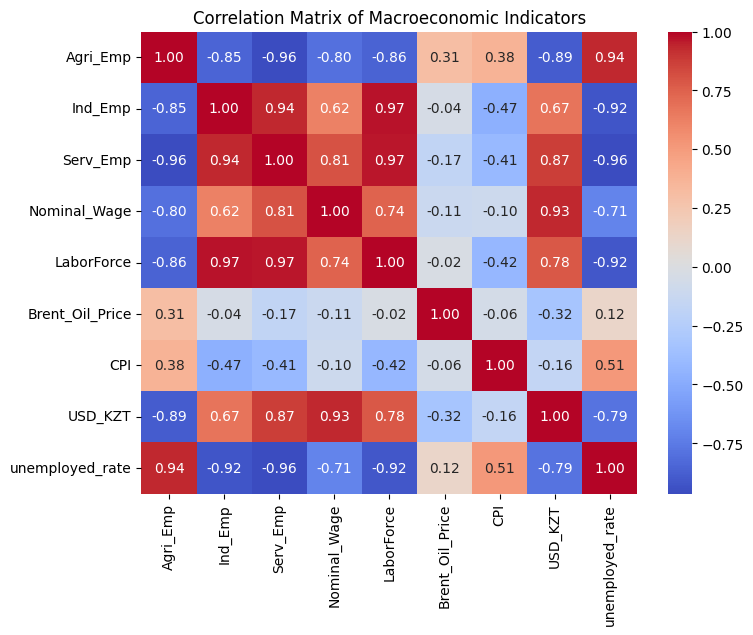

In [80]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_final.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Macroeconomic Indicators")

plt.show()

In [10]:
df_target

,UnemploymentRate
Date,
2010-01-01,6.3
2010-02-01,6.2
2010-03-01,6.1
2010-04-01,6.0
2010-05-01,5.8
...,...
2025-08-01,4.6
2025-09-01,4.6
2025-10-01,4.6


In [52]:
cpi.head()

,CPI
2011-01-01,103.600000
2011-02-01,102.836312
2011-03-01,102.258862
2011-04-01,101.800000
2011-05-01,101.484670
